## Using STG For Feature Selection

In [133]:
# --- import libraries ---
import pandas as pd
import numpy as np
import os
import shutil
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns

from stg import STG
import stg.utils as utils
import numpy as np
import torch
import time


PARTICIPANT_DATA_PATH = './participant_data/'

'datasets' should have a following structure:

```{python}
    datasets = {'train': {'x': (n_train, d) observations (dtype = float32),
                          't': (n_train) event times (dtype = float32),
                          'e': (n_train) event indicators (dtype = int32)},
                'test': {'x': (n_test, d) observations (dtype = float32),
                          't': (n_test) event times (dtype = float32),
                          'e': (n_test) event indicators (dtype = int32)},
                'valid': {'x': (n_valid, d) observations (dtype = float32),
                          't': (n_valid) event times (dtype = float32),
                          'e': (n_valid) event indicators (dtype = int32)}}
```

In [134]:
from utilities.preprocess import preprocess

index_event = "Borrow"
outcome_event = "Liquidated"
dataset_path = os.path.join(index_event, outcome_event)

train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))
test_features_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'test_features.csv'))
X_train, y_train, X_test_processed = preprocess(train_df, test_features_df)
lifelines_train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

In [135]:
lifelines_train_df.head()

,userBorrowSum,marketWithdrawAvgAmount,marketDepositAvgAmountUSD,sinDayOfMonth,userSecondsSinceFirstTransaction,timeOfDay,userActiveDaysWeekly,userLiquidationCount,userActiveDaysMonthly,userRepayCount,...,userSecondsSincePreviousTransaction,marketBorrowSumUSD,userRepaySum,logAmountUSD,marketDepositCount,marketRepayAvgAmountUSD,sinQuarter,marketLiquidationAvgAmount,timeDiff,status
0,-0.398558,-2.489321,-2.099994,0.289315,-0.785666,-0.570639,-0.396655,-0.156334,-0.892979,-0.402879,...,-0.079284,-1.733569,-0.398471,-1.254174,-1.577749,-2.370232,1.542022,-0.932965,75264503.0,0.0
1,-0.398558,-2.487828,-2.099970,-0.306477,-0.797257,-0.545239,-1.190754,-0.156334,-1.072193,-0.402879,...,-0.130458,-1.733569,-0.398471,-1.382937,-1.577674,-2.370232,1.542022,-0.932965,75091115.0,0.0
2,-0.398558,-2.487828,-2.097217,-0.306477,-0.797492,-0.276081,-1.190754,-0.156334,-1.072193,-0.402879,...,-0.132896,-1.733569,-0.398471,-1.254154,-1.577637,-2.370232,1.542022,-0.932965,75084884.0,0.0
3,-0.398558,-2.487828,-2.097217,-0.306477,-0.797489,-0.274353,-1.190754,-0.156334,-1.072193,-0.402879,...,-0.133089,-1.733569,-0.398471,-0.977241,-1.577637,-2.370232,1.542022,-0.932965,75084844.0,0.0
4,-0.398558,-2.487828,-2.095696,-0.306477,-0.797487,-0.052927,-1.190754,-0.156334,-1.072193,-0.402879,...,-0.132848,-1.733569,-0.398471,-1.281682,-1.577600,-2.370232,1.542022,-0.932965,75079718.0,0.0


In [136]:
original_columns = (lifelines_train_df.keys()).to_list()
print(len(original_columns))

80


In [137]:
# separate features (X), times (t), and events (e)
X = lifelines_train_df.drop(columns=["timeDiff", "status"]).values.astype(np.float32)
t = lifelines_train_df["timeDiff"].values.astype(np.float32)
e = lifelines_train_df["status"].values.astype(np.int32)

In [138]:
from sklearn.model_selection import train_test_split

train_valid_df, test_df = train_test_split(lifelines_train_df, test_size=0.2, random_state=42)
train_df, valid_df = train_test_split(train_valid_df, test_size=0.2, random_state=42)

# helper function to extract X, t, e
def extract_X_t_e(df):
    X = df.drop(columns=["timeDiff", "status"]).values.astype(np.float32)
    t = df["timeDiff"].values.astype(np.float32)
    e = df["status"].values.astype(np.int32)
    return X, t, e

# extract for each split
X_train, t_train, e_train = extract_X_t_e(train_df)
X_valid, t_valid, e_valid = extract_X_t_e(valid_df)
X_test, t_test, e_test = extract_X_t_e(test_df)

# build dictionary
datasets = {
    'train': {'X': X_train, 'T': t_train, 'E': e_train},
    'valid': {'X': X_valid, 'T': t_valid, 'E': e_valid},
    'test':  {'X': X_test,  'T': t_test,  'E': e_test}
}

# Check
for split in datasets:
    print(f"{split} X: {datasets[split]['X'].shape}, T: {datasets[split]['T'].shape}, E: {datasets[split]['E'].shape}")


train X: (566980, 78), T: (566980,), E: (566980,)
valid X: (141746, 78), T: (141746,), E: (141746,)
test X: (177182, 78), T: (177182,), E: (177182,)


In [139]:
for split in datasets:
    print(f"{split} X: {datasets[split]['X'].shape}, T: {datasets[split]['T'].shape}, E: {datasets[split]['E'].shape}")

train X: (566980, 78), T: (566980,), E: (566980,)
valid X: (141746, 78), T: (141746,), E: (141746,)
test X: (177182, 78), T: (177182,), E: (177182,)


In [140]:
import collections
import collections.abc

collections.Sequence = collections.abc.Sequence
collections.Set = collections.abc.Set
collections.Mapping = collections.abc.Mapping


device = "cpu"
feature_selection = True

# Get training data from datasets dictionary
train_data = datasets['train']
valid_data = datasets['train']

# Initialize STG model
model = STG(
    task_type='cox',
    input_dim=X_train.shape[1],      # number of features
    output_dim=1,
    hidden_dims=[60, 20, 3],
    activation='selu',
    optimizer='Adam',
    learning_rate=0.0005,
    batch_size=X_train.shape[0],      # full batch
    feature_selection=feature_selection,
    sigma=0.5,
    lam=0.004,
    random_state=1,
    device=device,
)

In [141]:
now = time.time()

model.fit(train_data['X'], 
          {'E': train_data['E'], 
           'T': train_data['T']}, 
           nr_epochs=500,
           valid_X=valid_data['X'], 
           valid_y={'E': valid_data['E'], 
           'T': valid_data['T']}, 
           print_interval=100,)

print("Passed Time: {}".format(time.time() - now))

Epoch: 100: CI=0.767811 loss=75.559944 valid_CI=0.783176 valid_loss=11.919930
Epoch: 200: CI=0.811741 loss=72.922264 valid_CI=0.821829 valid_loss=11.602594
Epoch: 300: CI=0.827815 loss=70.250168 valid_CI=0.825310 valid_loss=11.531660
Epoch: 400: CI=0.813150 loss=67.380379 valid_CI=0.830781 valid_loss=11.520107
Epoch: 500: CI=0.804982 loss=64.374443 valid_CI=0.830400 valid_loss=11.518598
Passed Time: 2514.882138490677


In [142]:
test_data = datasets['test']

model.evaluate(test_data['X'], {'E': test_data['E'], 'T': test_data['T']})

 test_CI=0.837610 test_loss=10.315579


In [143]:
model.get_gates(mode='prob')
importance = (model.get_gates(mode='prob'))
print(importance)

[0.2464967  0.22186258 0.22012523 0.23210871 0.21996644 0.22748345
 0.22826865 0.23325503 0.21264377 0.24302757 0.21005672 0.24286881
 0.21036237 0.24205947 0.22840086 0.22099194 0.21721286 0.23970485
 0.2457731  0.22572601 0.2332994  0.24396312 0.22346184 0.21593496
 0.20789072 0.23690605 0.22678375 0.22414246 0.22665486 0.22831675
 0.23228061 0.2177015  0.2307061  0.23820314 0.23230982 0.22084591
 0.22006387 0.23091555 0.21815461 0.22941649 0.23745883 0.22208562
 0.21967259 0.23738569 0.23991176 0.23819691 0.22651935 0.23174432
 0.21837035 0.22567758 0.20999274 0.22369948 0.23966926 0.21683058
 0.23890617 0.23028237 0.22259665 0.2131741  0.2185905  0.22861743
 0.21299517 0.22833186 0.23110637 0.2270847  0.23377883 0.2161937
 0.22816744 0.22962937 0.23845124 0.23674393 0.2374565  0.21938655
 0.21817848 0.23733458 0.21021235 0.23673415 0.21577984 0.21781409]


In [144]:
new_df = train_df.copy()
new_df = new_df.drop(["status", "timeDiff"], axis=1)
features = (new_df.columns).tolist()
len(features), len(train_df.keys())

(78, 80)

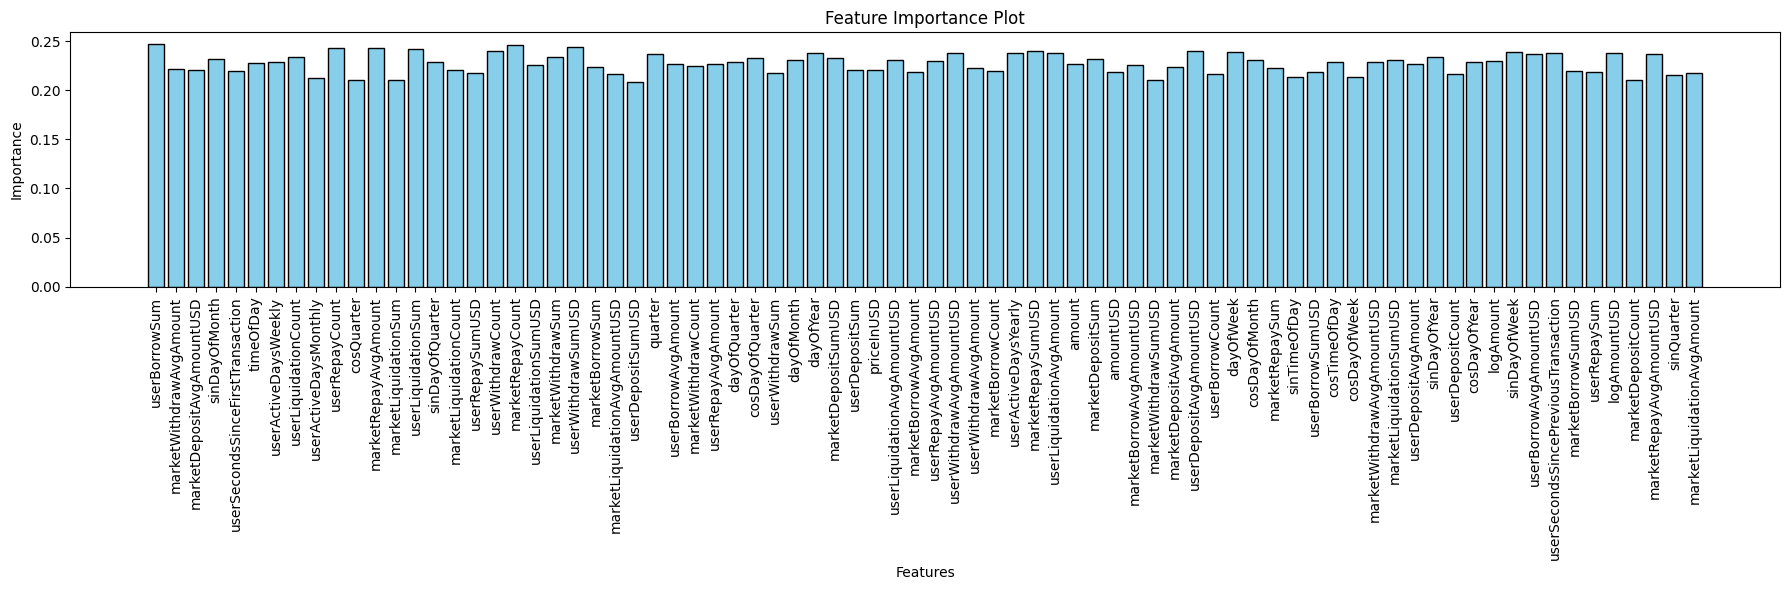

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.bar(features, importance, width=0.8, color='skyblue', edgecolor='black')

plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)  # rotate labels to prevent overlap
plt.title("Feature Importance Plot")
plt.tight_layout()  # adjusts layout to prevent clipping of labels
plt.show()

## COX Model Using The Selected Features

In [146]:
##--  print the importance of the features
print(len(importance))
print(importance)

78
[0.2464967  0.22186258 0.22012523 0.23210871 0.21996644 0.22748345
 0.22826865 0.23325503 0.21264377 0.24302757 0.21005672 0.24286881
 0.21036237 0.24205947 0.22840086 0.22099194 0.21721286 0.23970485
 0.2457731  0.22572601 0.2332994  0.24396312 0.22346184 0.21593496
 0.20789072 0.23690605 0.22678375 0.22414246 0.22665486 0.22831675
 0.23228061 0.2177015  0.2307061  0.23820314 0.23230982 0.22084591
 0.22006387 0.23091555 0.21815461 0.22941649 0.23745883 0.22208562
 0.21967259 0.23738569 0.23991176 0.23819691 0.22651935 0.23174432
 0.21837035 0.22567758 0.20999274 0.22369948 0.23966926 0.21683058
 0.23890617 0.23028237 0.22259665 0.2131741  0.2185905  0.22861743
 0.21299517 0.22833186 0.23110637 0.2270847  0.23377883 0.2161937
 0.22816744 0.22962937 0.23845124 0.23674393 0.2374565  0.21938655
 0.21817848 0.23733458 0.21021235 0.23673415 0.21577984 0.21781409]


In [147]:
roundoff_imp = [ round(i, 4) for i in importance ]
print(roundoff_imp)

[np.float32(0.2465), np.float32(0.2219), np.float32(0.2201), np.float32(0.2321), np.float32(0.22), np.float32(0.2275), np.float32(0.2283), np.float32(0.2333), np.float32(0.2126), np.float32(0.243), np.float32(0.2101), np.float32(0.2429), np.float32(0.2104), np.float32(0.2421), np.float32(0.2284), np.float32(0.221), np.float32(0.2172), np.float32(0.2397), np.float32(0.2458), np.float32(0.2257), np.float32(0.2333), np.float32(0.244), np.float32(0.2235), np.float32(0.2159), np.float32(0.2079), np.float32(0.2369), np.float32(0.2268), np.float32(0.2241), np.float32(0.2267), np.float32(0.2283), np.float32(0.2323), np.float32(0.2177), np.float32(0.2307), np.float32(0.2382), np.float32(0.2323), np.float32(0.2208), np.float32(0.2201), np.float32(0.2309), np.float32(0.2182), np.float32(0.2294), np.float32(0.2375), np.float32(0.2221), np.float32(0.2197), np.float32(0.2374), np.float32(0.2399), np.float32(0.2382), np.float32(0.2265), np.float32(0.2317), np.float32(0.2184), np.float32(0.2257), np.f

In [148]:
avg_roundoff_imp = np.average(roundoff_imp)
print(avg_roundoff_imp)

avg_roundoff_imp = round(avg_roundoff_imp, 3)
print(avg_roundoff_imp)

0.2271987
0.227


In [149]:
##-- select features based on threshold --##
all_cols = ((lifelines_train_df.drop(["timeDiff", "status"], axis=1)).keys()).to_list()
selected_cols = []
for i in range(len(importance)):
    if importance[i] > avg_roundoff_imp:
        selected_cols.append(all_cols[i])

selected_cols.append("timeDiff")
selected_cols.append("status")
print(len(selected_cols))

43


In [150]:
new_selected_df = lifelines_train_df[selected_cols]
new_selected_df.head()

,userBorrowSum,sinDayOfMonth,timeOfDay,userActiveDaysWeekly,userLiquidationCount,userRepayCount,marketRepayAvgAmount,userLiquidationSum,sinDayOfQuarter,userWithdrawCount,...,sinDayOfYear,cosDayOfYear,logAmount,sinDayOfWeek,userBorrowAvgAmountUSD,userSecondsSincePreviousTransaction,logAmountUSD,marketRepayAvgAmountUSD,timeDiff,status
0,-0.398558,0.289315,-0.570639,-0.396655,-0.156334,-0.402879,-2.342678,-0.045902,-1.277559,-0.057835,...,1.387732,0.373454,-1.011497,1.050891,-0.485221,-0.079284,-1.254174,-2.370232,75264503.0,0.0
1,-0.398558,-0.306477,-0.545239,-1.190754,-0.156334,-0.402879,-2.342678,-0.045902,-1.189663,-0.057835,...,1.401740,0.325844,-1.139566,0.557057,-0.485246,-0.130458,-1.382937,-2.370232,75091115.0,0.0
2,-0.398558,-0.306477,-0.276081,-1.190754,-0.156334,-0.402879,-2.342678,-0.045902,-1.189663,-0.057835,...,1.401740,0.325844,-1.011497,0.557057,-0.485221,-0.132896,-1.254154,-2.370232,75084884.0,0.0
3,-0.398558,-0.306477,-0.274353,-1.190754,-0.156334,-0.402879,-2.342678,-0.045902,-1.189663,-0.057835,...,1.401740,0.325844,-0.736064,0.557057,-0.485158,-0.133089,-0.977241,-2.370232,75084844.0,0.0
4,-0.398558,-0.306477,-0.052927,-1.190754,-0.156334,-0.402879,-2.342678,-0.045902,-1.189663,-0.057835,...,1.401740,0.325844,-1.038890,0.557057,-0.485227,-0.132848,-1.281682,-2.370232,75079718.0,0.0


In [151]:
model = CoxPHFitter(penalizer=0.2)
model.fit(new_selected_df, duration_col='timeDiff', event_col='status')

<lifelines.CoxPHFitter: fitted with 885908 total observations, 861864 right-censored observations>

In [154]:
model.print_summary()

<lifelines.CoxPHFitter: fitted with 885908 total observations, 861864 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
                penalizer = 0.2
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 885908
number of events observed = 24044
   partial log-likelihood = -320996.34
         time fit was run = 2025-09-21 13:58:00 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
userBorrowSum                       -0.04      0.96      0.00           -0.05           -0.04                0.96                0.96
sinDayOfMonth                        0.01      1.01      0.00            0.01            0.01                1.01                1.01
timeOfDay                            0.01      1.01      0.00            0.00            0.01                1.00                1.01
userActiveDaysWeekly                 0.03      1.03      0.00            0.03            0.04                1.03                1.04
userLiquidationCount                 0.13      1.14      0.00            0.13            0.13                1.13                1.14
userRepayCount                      -0.04      0.96      0.00           -0.05           -0.04                0.96                0.96
marketRepayAvgAmount                 0.00      1.00      0.00           -0.00            0.01                1.00                1.01
userLiquidationSum                   0.01      1.01      0.00            0.01            0.01                1.01                1.01
sinDayOfQuarter                      0.01      1.01      0.00            0.00            0.01                1.00                1.01
userWithdrawCount                   -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
marketRepayCount                    -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
marketWithdrawSum                   -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
userWithdrawSumUSD                  -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
quarter                             -0.02      0.98      0.00           -0.02           -0.01                0.98                0.99
dayOfQuarter                        -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
cosDayOfQuarter                      0.01      1.01      0.00            0.00            0.01                1.00                1.01
dayOfMonth                          -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
dayOfYear                           -0.02      0.98      0.00           -0.02           -0.01                0.98                0.99
marketDepositSumUSD                  0.00      1.00      0.00           -0.00            0.01                1.00                1.01
userLiquidationAvgAmountUSD          0.03      1.03      0.00            0.02            0.03                1.02                1.03
userRepayAvgAmountUSD               -0.04      0.96      0.00           -0.05           -0.04                0.95                0.96
userWithdrawAvgAmountUSD            -0.02      0.98      0.00           -0.03           -0.02                0.97                0.98
userActiveDaysYearly                 0.02      1.02      0.00            0.01            0.02                1.01                1.02
marketRepaySumUSD                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
userLiquidationAvgAmount             0.03      1.03      0.00            0.0

In [153]:
# X_train = new_selected_df.drop(["timeDiff", "status"], axis=1)
# y_train = new_selected_df["timeDiff", "status"]

In [ ]:
# # model.print_summary()
# from lifelines.utils import concordance_index

# train_risk = model.predict_partial_hazard(X_train)

# # --- c-index using partial hazard as risk scores ---
# c_index = concordance_index(
#     new_selected_df["timeDiff"],       # observed times
#     -train_risk,                          # negative because higher risk -> shorter survival
#     new_selected_df["status"]          # event indicator
# )
# print(f"C-Index: {c_index:.3f}")

#### Oversampling

In [ ]:
new_selected_df.head()

,userBorrowSum,sinDayOfMonth,userSecondsSinceFirstTransaction,userActiveDaysWeekly,userLiquidationCount,userRepayCount,cosQuarter,marketRepayAvgAmount,userLiquidationSum,sinDayOfQuarter,...,cosDayOfWeek,marketWithdrawAvgAmountUSD,cosDayOfYear,logAmount,marketBorrowSumUSD,marketDepositCount,marketRepayAvgAmountUSD,sinQuarter,timeDiff,status
0,-0.398558,0.289315,-0.785666,-0.396655,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.277559,...,0.978175,-2.456185,0.373454,-1.011497,-1.733569,-1.577749,-2.370232,1.542022,75264503.0,0.0
1,-0.398558,-0.306477,-0.797257,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-1.139566,-1.733569,-1.577674,-2.370232,1.542022,75091115.0,0.0
2,-0.398558,-0.306477,-0.797492,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-1.011497,-1.733569,-1.577637,-2.370232,1.542022,75084884.0,0.0
3,-0.398558,-0.306477,-0.797489,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-0.736064,-1.733569,-1.577637,-2.370232,1.542022,75084844.0,0.0
4,-0.398558,-0.306477,-0.797487,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-1.038890,-1.733569,-1.577600,-2.370232,1.542022,75079718.0,0.0


In [ ]:
status_0_count = new_selected_df["status"].value_counts()[0]
status_1_count = new_selected_df["status"].value_counts()[1]
print(f"% of status=0: {status_0_count/(status_0_count + status_1_count):.2f}")
print(f"% of status=1: {status_1_count/(status_0_count + status_1_count):.2f}")

No of status=0: 861864
No of status=1: 24044
-----------------------------------------
% of status=0: 0.97
% of status=1: 0.03


In [ ]:
X_train_ = new_selected_df.drop(["timeDiff", "status"], axis=1)
y_train_ = new_selected_df[["timeDiff", "status"]]

In [ ]:
from imblearn.over_sampling import ADASYN
from collections import Counter

print("Before:", Counter(y_train))

adasyn = ADASYN(sampling_strategy=0.1, random_state=42, n_neighbors=100)  # n_neighbors can be tuned
X_res, y_res = adasyn.fit_resample(X_train, y_train)

print("After:", Counter(y_res))

Original events: 24044 (2.7%)
Need to generate 128049 synthetic events
New event ratio: 15.0%
Original shape: (885908, 38)
New shape: (1013957, 38)
Events increased from 24044 to 152093.0


In [ ]:
augmented_train_df = pd.concat([X_res, y_res.reset_index(drop=True)], axis=1)
augmented_train_df.head()

,userBorrowSum,sinDayOfMonth,userSecondsSinceFirstTransaction,userActiveDaysWeekly,userLiquidationCount,userRepayCount,cosQuarter,marketRepayAvgAmount,userLiquidationSum,sinDayOfQuarter,...,cosDayOfWeek,marketWithdrawAvgAmountUSD,cosDayOfYear,logAmount,marketBorrowSumUSD,marketDepositCount,marketRepayAvgAmountUSD,sinQuarter,timeDiff,status
0,-0.398558,0.289315,-0.785666,-0.396655,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.277559,...,0.978175,-2.456185,0.373454,-1.011497,-1.733569,-1.577749,-2.370232,1.542022,75264503.0,0.0
1,-0.398558,-0.306477,-0.797257,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-1.139566,-1.733569,-1.577674,-2.370232,1.542022,75091115.0,0.0
2,-0.398558,-0.306477,-0.797492,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-1.011497,-1.733569,-1.577637,-2.370232,1.542022,75084884.0,0.0
3,-0.398558,-0.306477,-0.797489,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-0.736064,-1.733569,-1.577637,-2.370232,1.542022,75084844.0,0.0
4,-0.398558,-0.306477,-0.797487,-1.190754,-0.156334,-0.402879,-0.095643,-2.342678,-0.045902,-1.189663,...,-1.183281,-2.455039,0.325844,-1.038890,-1.733569,-1.577600,-2.370232,1.542022,75079718.0,0.0


In [ ]:
status_0_count = augmented_train_df["status"].value_counts()[0]
status_1_count = augmented_train_df["status"].value_counts()[1]
print(f"% of status=0: {status_0_count/(status_0_count + status_1_count):.2f}")
print(f"% of status=1: {status_1_count/(status_0_count + status_1_count):.2f}")

% of status=0: 0.85
% of status=1: 0.15


In [ ]:
model = CoxPHFitter(penalizer=0.2)
model.fit(augmented_train_df, duration_col='timeDiff', event_col='status')

<lifelines.CoxPHFitter: fitted with 1.01396e+06 total observations, 861864 right-censored observations>

In [ ]:
model.print_summary()

<lifelines.CoxPHFitter: fitted with 1.01396e+06 total observations, 861864 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1.01396e+06
number of events observed = 152093
   partial log-likelihood = -1957686.10
         time fit was run = 2025-09-21 13:10:42 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                         
userBorrowSum                    -0.17      0.84      0.00           -0.18           -0.17                0.84                0.85
sinDayOfMonth                     0.04      1.04      0.00            0.04            0.05                1.04                1.05
userSecondsSinceFirstTransaction  0.04      1.04      0.00            0.04            0.05                1.04                1.05
userActiveDaysWeekly              0.19      1.21      0.00            0.19            0.19                1.20                1.21
userLiquidationCount              0.13      1.14      0.00            0.13            0.13                1.14                1.14
userRepayCount                   -0.18      0.83      0.00           -0.19           -0.18                0.83                0.84
cosQuarter                        0.00      1.00      0.00           -0.00            0.01                1.00                1.01
marketRepayAvgAmount             -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
userLiquidationSum                0.03      1.03      0.00            0.03            0.03                1.03                1.03
sinDayOfQuarter                   0.02      1.02      0.00            0.02            0.03                1.02                1.03
marketLiquidationCount            0.00      1.00      0.00            0.00            0.01                1.00                1.01
userWithdrawCount                -0.02      0.98      0.00           -0.03           -0.02                0.97                0.98
marketRepayCount                  0.03      1.03      0.00            0.03            0.04                1.03                1.04
marketLiquidationAvgAmountUSD     0.01      1.01      0.00            0.00            0.01                1.00                1.01
userDepositSumUSD                -0.04      0.96      0.00           -0.05           -0.03                0.96                0.97
quarter                          -0.04      0.96      0.00           -0.05           -0.04                0.95                0.96
userBorrowAvgAmount              -0.23      0.80      0.00           -0.23           -0.22                0.79                0.80
marketWithdrawCount               0.01      1.01      0.00            0.00            0.01                1.00                1.01
dayOfQuarter                      0.02      1.02      0.00            0.01            0.02                1.01                1.02
cosDayOfQuarter                   0.01      1.01      0.00            0.01            0.02                1.01                1.02
userWithdrawSum                  -0.03      0.97      0.00           -0.04           -0.03                0.96                0.97
dayOfYear                        -0.04      0.96      0.00           -0.04           -0.03                0.96                0.97
marketDepositSumUSD               0.04      1.04      0.00            0.03            0.04                1.03                1.04
userDepositSum                   -0.03      0.97      0.00           -0.04           -0.03                0.96                0.97
marketBorrowAvgAmount             0.04      1.04      0.00            0.03            0.04                1.03                1.04
userWithdra